In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(
    "/content/Telco_Customer_Churn_Dataset  (3).csv"
)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

,0
tenure,int64
MonthlyCharges,float64
TotalCharges,float64


In [10]:
tenure_analysis = df.groupby("tenure").agg(
    AverageMonthlyCharges=("MonthlyCharges", "mean"),
    AverageTotalCharges=("TotalCharges", "mean"),
    CustomerCount=("customerID", "count")
)

tenure_analysis.head()

,AverageMonthlyCharges,AverageTotalCharges,CustomerCount
tenure,,,
0,41.418182,NaN,11
1,50.485808,50.485808,613
2,57.206303,114.332353,238
3,58.015000,174.690000,200
4,57.432670,230.530682,176


In [11]:
churn_by_tenure = df.groupby("tenure")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

churn_by_tenure.head()

,Churn
tenure,
0,0.000000
1,61.990212
2,51.680672
3,47.000000
4,47.159091


In [12]:
tenure_analysis["ChurnRate"] = churn_by_tenure

tenure_analysis.head()

,AverageMonthlyCharges,AverageTotalCharges,CustomerCount,ChurnRate
tenure,,,,
0,41.418182,NaN,11,0.000000
1,50.485808,50.485808,613,61.990212
2,57.206303,114.332353,238,51.680672
3,58.015000,174.690000,200,47.000000
4,57.432670,230.530682,176,47.159091


In [13]:
gender_churn = df.groupby("gender")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

gender_churn

,Churn
gender,
Female,26.920872
Male,26.160338


In [14]:
senior_churn = df.groupby("SeniorCitizen")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

senior_churn

,Churn
SeniorCitizen,
0,23.606168
1,41.681261


In [15]:
senior_churn.index = senior_churn.index.map({
    0: "Non-Senior Citizen",
    1: "Senior Citizen"
})

senior_churn

,Churn
SeniorCitizen,
Non-Senior Citizen,23.606168
Senior Citizen,41.681261


In [16]:
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

payment_churn

,Churn
PaymentMethod,
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101
Electronic check,45.285412
Mailed check,19.106700


In [17]:
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

contract_churn

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


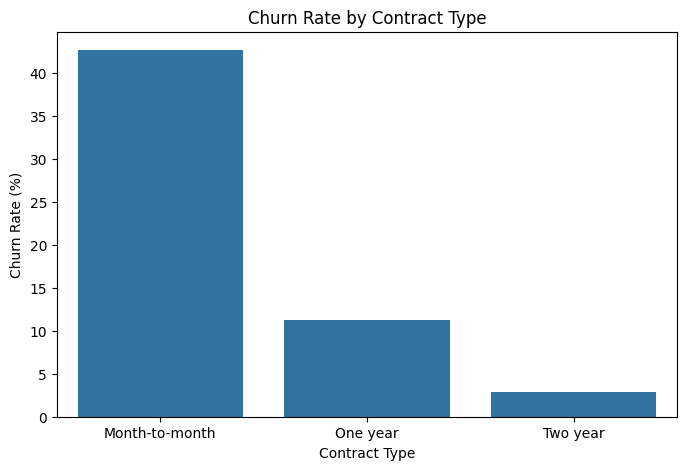

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")

plt.show()

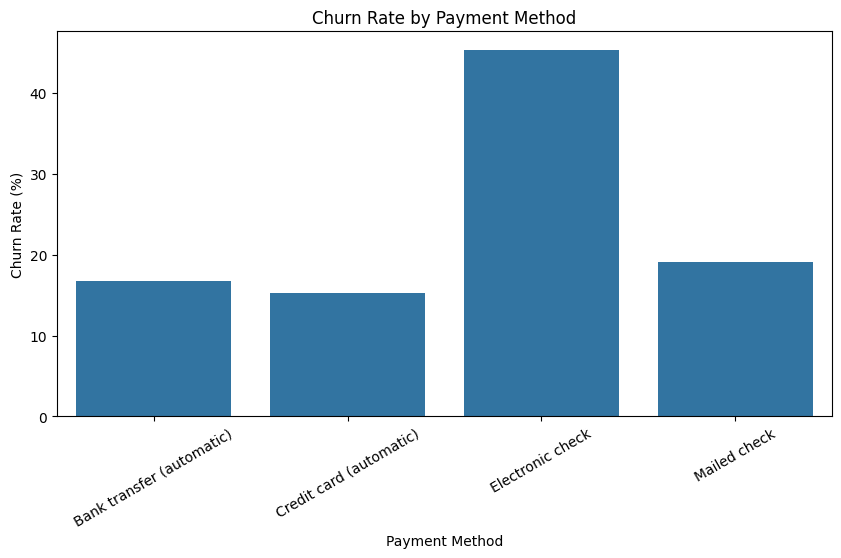

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")

plt.xticks(rotation=30)

plt.show()

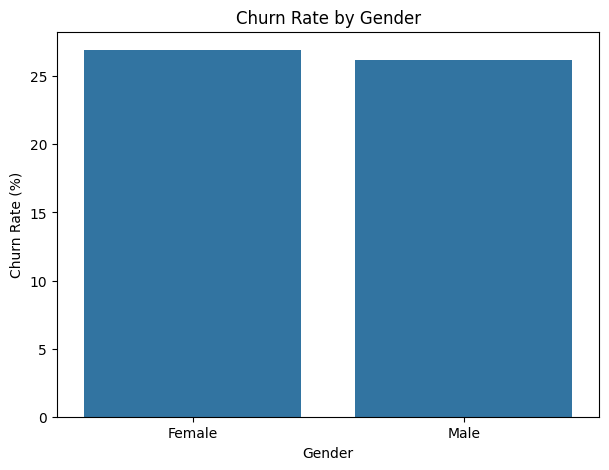

In [20]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Gender")

plt.show()

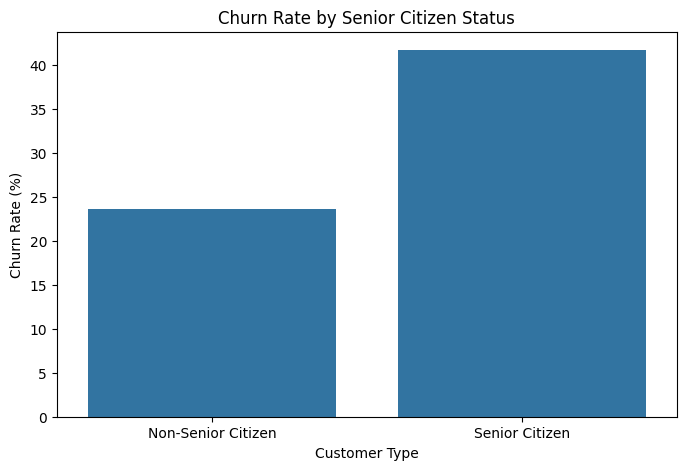

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Senior Citizen Status")

plt.show()

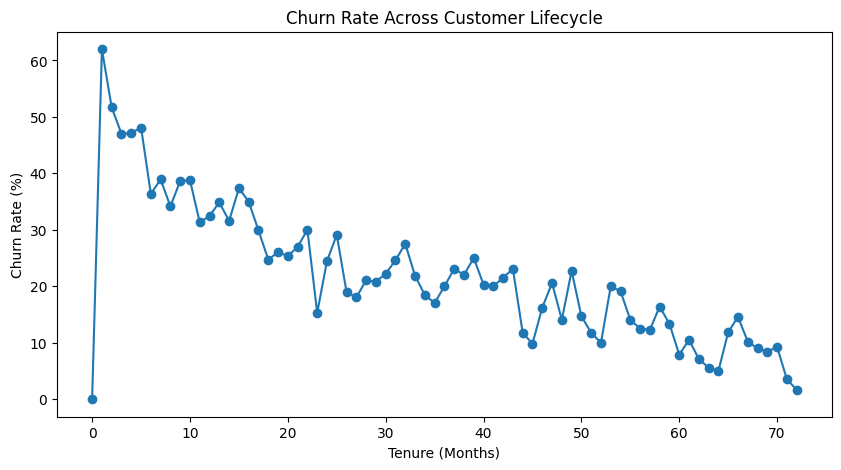

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    churn_by_tenure.index,
    churn_by_tenure.values,
    marker="o"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate Across Customer Lifecycle")

plt.show()